# Problem Statement: Advertising Dataset

## Objective
The objective of this project is to analyze the relationship between advertising expenditure across different media channels and product sales, and to build regression models that can accurately predict sales based on advertising budgets.

## Dataset Description
The dataset contains information about advertising spending in three different media channels:

- TV advertising budget
- Radio advertising budget
- Newspaper advertising budget

It also includes the corresponding:

- Sales of the product

Each row represents a different advertising campaign with its associated spending and resulting sales.

## Problem Definition
You are required to:

1. Perform Exploratory Data Analysis (EDA) to understand:
   - The distribution of each feature
   - The relationship between advertising channels and sales
   - Correlation between variables

2. Build and evaluate multiple regression models, including:
   - Simple Linear Regression
   - Multiple Linear Regression
   - Polynomial Regression
   - Tree-based models (Decision Tree, Random Forest)

3. Compare the performance of these models using appropriate evaluation metrics such as:
   - Mean Squared Error (MSE)
   - Root Mean Squared Error (RMSE)
   - R² Score

## Goal
The final goal is to identify:
- Which advertising channels have the most impact on sales
- Which regression model provides the best prediction accuracy

## Expected Outcome
By the end of this project, you should be able to:
- Understand how advertising budgets influence sales
- Select important features
- Build and compare different regression models
- Draw meaningful business insights from the data

# Importing the data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./advertising.csv')

In [28]:
df.shape, df.describe()

((200, 4),
                TV       Radio   Newspaper       Sales
 count  200.000000  200.000000  200.000000  200.000000
 mean   147.042500   23.264000   30.554000   15.130500
 std     85.854236   14.846809   21.778621    5.283892
 min      0.700000    0.000000    0.300000    1.600000
 25%     74.375000    9.975000   12.750000   11.000000
 50%    149.750000   22.900000   25.750000   16.000000
 75%    218.825000   36.525000   45.100000   19.050000
 max    296.400000   49.600000  114.000000   27.000000)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [30]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

# Exploratory Data Analysis (EDA)

<Axes: xlabel='TV', ylabel='Count'>

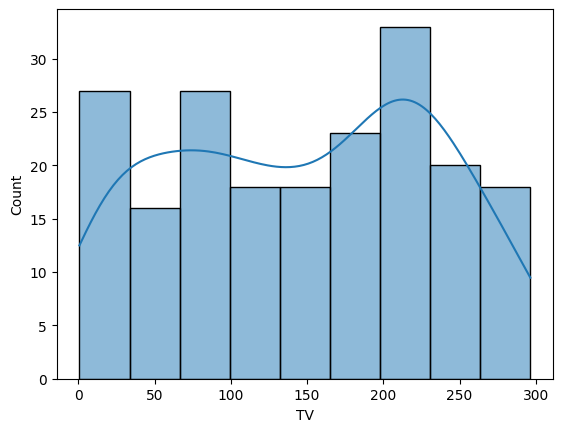

In [31]:
sns.histplot(df['TV'], kde=True)

<Axes: xlabel='Radio', ylabel='Count'>

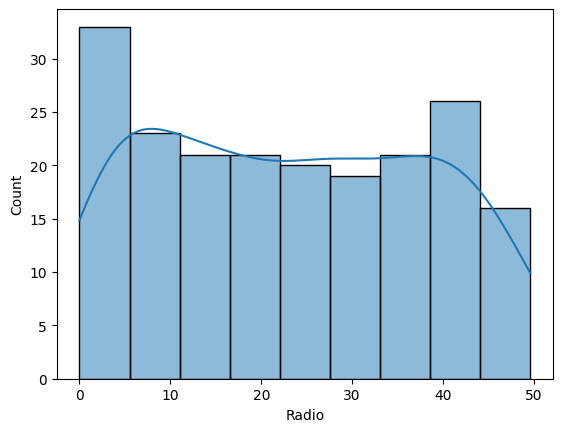

In [32]:
sns.histplot(df['Radio'], kde=True)

<Axes: xlabel='Newspaper', ylabel='Count'>

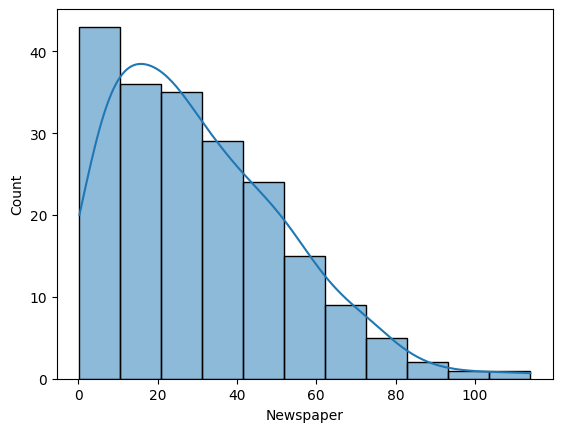

In [33]:
sns.histplot(df['Newspaper'], kde=True)

<Axes: xlabel='Newspaper', ylabel='Count'>

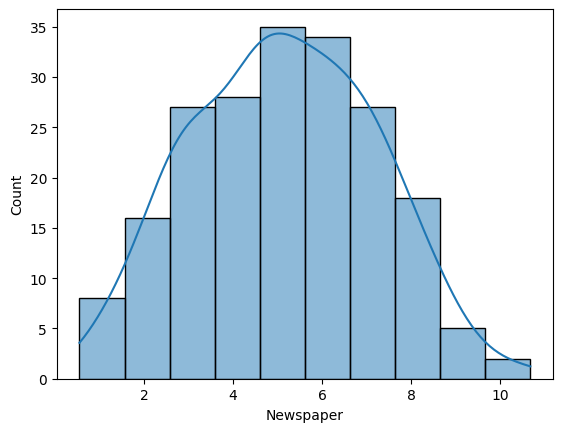

In [34]:
sns.histplot(np.sqrt(df['Newspaper']), kde=True)

<Axes: xlabel='TV', ylabel='Sales'>

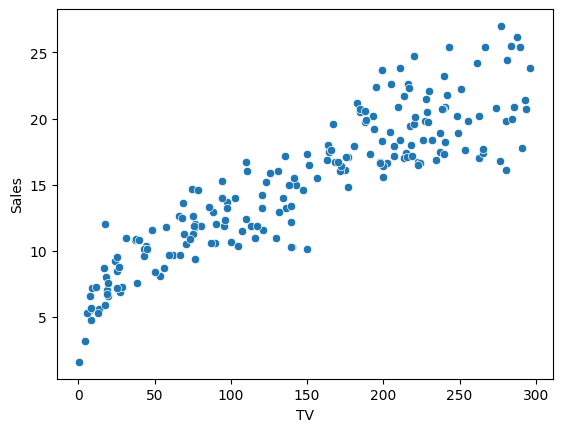

In [35]:
sns.scatterplot(x="TV", y="Sales", data=df)

<Axes: xlabel='Radio', ylabel='Sales'>

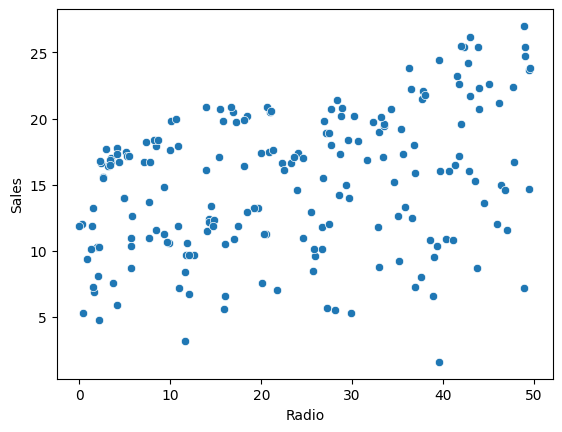

In [36]:
sns.scatterplot(x="Radio", y="Sales", data=df)

<Axes: xlabel='Newspaper', ylabel='Sales'>

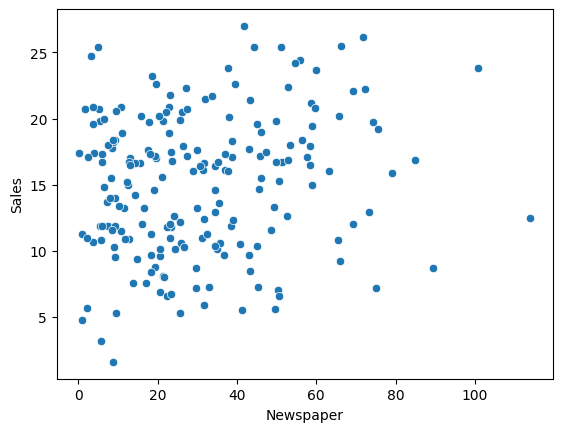

In [37]:
sns.scatterplot(x="Newspaper", y="Sales", data=df)

<Axes: >

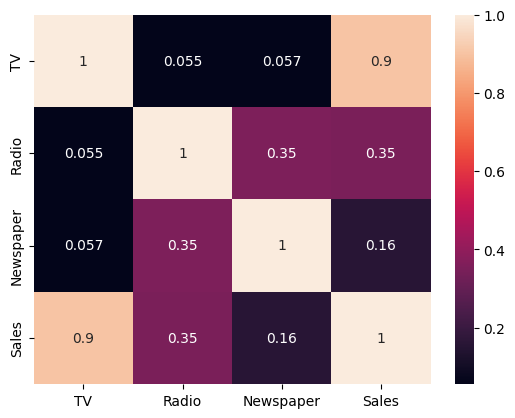

In [38]:
corr = df.corr()
sns.heatmap(corr, annot=True)

## Observations

### Histplot Observations
- TV is almost evenly distributed and does not show any major skewness  
- Radio is also fairly distributed, but shows a slight skewness  
- Newspaper is heavily skewed towards the right, with most values concentrated on the lower side

### After applying transformations on Newspaper:
- np.sqrt makes the distribution look more like a bell curve (approximately normal)

---

### Scatter Plot Observations
- **TV vs Sales** shows a strong positive correlation  
- **Radio vs Sales** shows a moderate positive correlation  
- **Newspaper vs Sales** shows no clear relationship  

---

### Correlation (Heatmap Confirmation)

| Comparison           | Correlation |
|---------------------|------------|
| TV vs Sales         | 0.90       |
| Radio vs Sales      | 0.35       |
| Newspaper vs Sales  | 0.16       |

---

### Multicollinearity Check

Multicollinearity is not present, as the correlations between independent features are low:

| Comparison           | Correlation |
|---------------------|------------|
| TV vs Radio         | 0.055      |
| TV vs Newspaper     | 0.057      |
| Radio vs Newspaper  | 0.35       |

---

## Final Observation

- TV is a strong predictor of Sales
- Radio is a moderate predictor and can improve the predictions
- Newspaper is a very weak predictor. Square root transformation can be applied to reduce skewness, but it may still not improve the predictions

# Data Preprocessing

In [39]:
X = df[['TV', 'Radio']]
y = df['Sales']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Modelling

## Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
lr_y_pred = lr.predict(X_test)

## Polynomial Regression

In [43]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

lr.fit(X_train_poly, y_train)
poly_y_pred = lr.predict(X_test_poly)

## Support Vector Regression (SVR)

In [44]:
from sklearn.preprocessing import StandardScaler
xss = StandardScaler()
X_train_scaled = xss.fit_transform(X_train)
X_test_scaled = xss.transform(X_test)
yss = StandardScaler()
y_train_scaled = yss.fit_transform(y_train.values.reshape(-1,1))

In [45]:
from sklearn.svm import SVR

svr = SVR(kernel="rbf")
svr.fit(X_train_scaled, y_train_scaled.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [46]:
y_pred = svr.predict(X_test_scaled).reshape(-1,1)
svr_y_pred = yss.inverse_transform(y_pred)

## Decision Tree Regression

In [47]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(random_state=0)
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [48]:
dtr_y_pred = dtr.predict(X_test)

## Random Forest Regression

In [49]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, random_state=0)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
rfr_y_pred = rfr.predict(X_test)

# Model Evaluation

In [51]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

def evaluate(y_test, y_pred, model_name):
    print(f"Model Name : {model_name}")
    print(f"R² Score = {r2_score(y_test, y_pred)}")
    print(f"MSE Error = {mean_squared_error(y_test, y_pred)}")
    print(f"RMSE Error = {root_mean_squared_error(y_test, y_pred)}\n")

In [52]:
evaluate(y_test, lr_y_pred, "Linear Regression")
evaluate(y_test, poly_y_pred, "Polynomial Regression")
evaluate(y_test, svr_y_pred, "SVR")
evaluate(y_test, dtr_y_pred, "Decision Tree Regression")
evaluate(y_test, rfr_y_pred, "Random Forest Regression")

Model Name : Linear Regression
R² Score = 0.9078797802624651
MSE Error = 2.846616122131541
RMSE Error = 1.6871917858179433

Model Name : Polynomial Regression
R² Score = 0.9545299490109975
MSE Error = 1.405074592616264
RMSE Error = 1.1853584236914436

Model Name : SVR
R² Score = 0.9513176089469942
MSE Error = 1.5043394341680354
RMSE Error = 1.2265151585561571

Model Name : Decision Tree Regression
R² Score = 0.9364343016915255
MSE Error = 1.9642499999999992
RMSE Error = 1.401517035215769

Model Name : Random Forest Regression
R² Score = 0.960793870606548
MSE Error = 1.2115125249999994
RMSE Error = 1.100687296646963



# Model Comparison

The performance of different regression models is evaluated using the following metrics:

- R² Score
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

|Model|R²|MSE|RMSE|
|---|---|---|---|
|Linear Regression|0.9087|2.8466|1.6871|
|Polynomial Regression|0.9545|1.405|1.1853|
|Support Vector Regression|0.9513|1.5043|1.2265|
|Decision Tree Regression|0.9346|1.9642|1.4015|
|Random Forest Regression|0.9607|1.2115|1.1006|

# Conclusion

- Among all the models, **Random Forest Regression** performed the best, achieving the highest R² score (0.9607) and the lowest error values (MSE and RMSE).
- **Polynomial Regression** and **Support Vector Regression (SVR)** also performed well, indicating the presence of some non-linear relationships in the data.
- **Linear Regression** showed comparatively lower performance, suggesting that a simple linear model is not sufficient to capture all patterns in the dataset.
- **Decision Tree Regression** performed moderately but was less accurate than Random Forest.

## Final Insight

- Models that can capture **non-linear relationships** (like Random Forest and Polynomial Regression) provide better predictions for this dataset.
- Overall, **Random Forest Regression** is the most suitable model for this problem.